In [3]:
import pandas as pd

In [4]:
data=pd.read_csv("TATACOFFEE13_21.csv")
data

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [5]:
column = "Close"

from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()

data1 = Ms.fit_transform(data[[column]])

print("Len:", data1.shape)

Len: (2225, 1)


In [6]:
training_size = round(len(data1) * 0.80)

print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [7]:
from sklearn.metrics import mean_squared_error

trends = ['n', 'c', 'ct', 'ct']
lags = [1, 2, 3, 4]

from statsmodels.tsa.ar_model import AutoReg

for i in lags:

    for td in trends:

        model = AutoReg(
            X_train,
            lags=i,
            trend=td
        )

        model_fit = model.fit()

        # Make prediction
        y_pred = model_fit.predict(
            len(X_train),
            len(data1) - 1
        )

        # Calculate MSE
        mse = mean_squared_error(
            y_test,
            y_pred
        )

        # Calculate RMSE
        rmse_value = mse ** 0.5

        print("Lag={0}, Trend={1}".format(i, td))
        print("MSE:", mse)
        print("RMSE:", rmse_value)
        print("***************")

Lag=1, Trend=n
MSE: 0.0034644227662105017
RMSE: 0.058859347313833695
***************
Lag=1, Trend=c
MSE: 0.0018805449368485523
RMSE: 0.043365250337667284
***************
Lag=1, Trend=ct
MSE: 0.02332857402067153
RMSE: 0.152736943863204
***************
Lag=1, Trend=ct
MSE: 0.02332857402067153
RMSE: 0.152736943863204
***************
Lag=2, Trend=n
MSE: 0.003536630045932716
RMSE: 0.059469572437782975
***************
Lag=2, Trend=c
MSE: 0.001216024556494223
RMSE: 0.034871543649431735
***************
Lag=2, Trend=ct
MSE: 0.022943396798261496
RMSE: 0.15147077869431283
***************
Lag=2, Trend=ct
MSE: 0.022943396798261496
RMSE: 0.15147077869431283
***************
Lag=3, Trend=n
MSE: 0.003533464899580025
RMSE: 0.05944295500376832
***************
Lag=3, Trend=c
MSE: 0.0012987369051811212
RMSE: 0.03603799252429471
***************
Lag=3, Trend=ct
MSE: 0.021678190398649943
RMSE: 0.14723515340654875
***************
Lag=3, Trend=ct
MSE: 0.021678190398649943
RMSE: 0.14723515340654875
*************

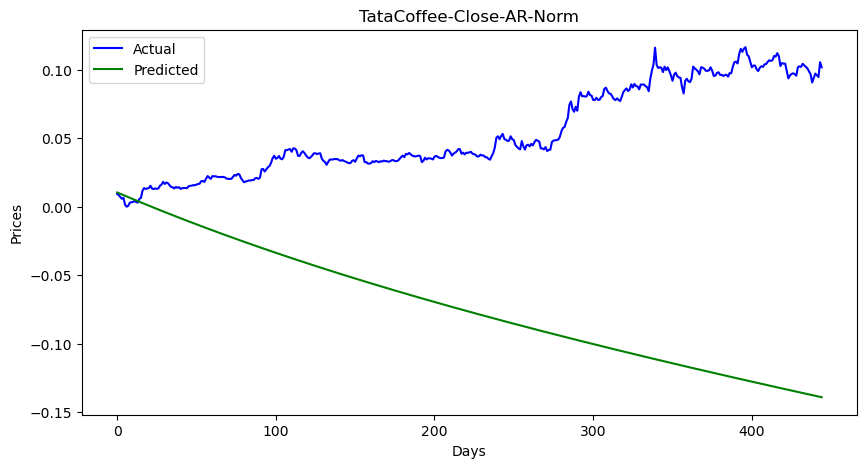

In [8]:
from stockFunctions import graph

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close-AR-Norm",
    "Days",
    "Prices"
)